# Predicting secondary completion rates with poverty measures


---


Juliana Cobb, Suzanne Crabtree, Hannah Facci, Addison Orndorff


In [ ]:
# importing packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

## Data Importing and Cleaning

In [ ]:
# read in raw data
df = pd.read_csv('/content/drive/MyDrive/UNC/combined_50.csv')

df.head()

,Country Name,Country Code,Series Name,Series Code,1976 [YR1976],1977 [YR1977],1978 [YR1978],1979 [YR1979],1980 [YR1980],1981 [YR1981],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,"Educational attainment, at least completed upp...",SE.SEC.CUAT.UP.MA.ZS,..,..,..,..,..,..,...,..,19.1655944883765,..,..,18.5248093853414,12.1000003814697,19.8488998413086,..,..,..
1,Afghanistan,AFG,"Educational attainment, at least completed upp...",SE.SEC.CUAT.UP.ZS,..,..,..,..,..,..,...,..,11.7771822147423,..,..,11.8347043333891,9.46000003814697,12.5973300933838,..,..,..
2,Afghanistan,AFG,"Educational attainment, at least completed upp...",SE.SEC.CUAT.UP.FE.ZS,..,..,..,..,..,..,...,..,4.24002751251591,..,..,4.97310527668358,5.19999980926514,5.70547008514404,..,..,..
3,Afghanistan,AFG,Poverty headcount ratio at $8.30 a day (2021 P...,SI.POV.UMIC,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Afghanistan,AFG,Poverty headcount ratio at national poverty li...,SI.POV.NAHC,..,..,..,..,..,..,...,54.5,..,..,47.1,..,..,..,..,..,..


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# the data needs to be organized before it can be cleaned. use multiindices
# sort the values by country first, then series
df.sort_values(['Country Name', 'Series Name'], inplace=True)

# add a simpler, searchable series column
df['Series'] = df['Series Name'].map({
    'Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)': 'ed_attain_fem',
    'Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)': 'ed_attain_male',
    'Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)': 'ed_attain_total',
    'Poverty headcount ratio at $8.30 a day (2021 PPP) (% of population)': 'poverty_ratio_wage',
    'Poverty headcount ratio at national poverty lines (% of population)': 'poverty_ratio_nat',
    'GDP per capita (constant 2015 US$)': 'GDP_const',
    'GDP per capita growth (annual %)': 'GDP_growth'

})

# drop empty buffer rows
df.dropna(subset=['Series'], inplace=True)

# set indices
df.set_index(['Country Name', 'Series'], inplace=True)

# remove extraneous columns, simplify column names, rearrange stuff
col = df.pop('Series Name')
df.insert(len(df.columns), 'Series Name', col)
df.drop(columns = ['Series Code', 'Country Code'], inplace=True)
df.columns = [col[:4] for col in df.columns]
df.rename(columns = {'Seri': 'Series Description'}, inplace=True)
df.replace('..', np.nan, inplace=True)
# filter to range 2002-2022
df.drop(columns = [str(year) for year in range(1976, 2002)], inplace=True)
df.drop(columns = [str(year) for year in range(2023, 2026)], inplace=True)

In [ ]:
# actual data cleaning

# sort by number of NaN per country name index
nan_counts = df.isnull().sum(axis=1).groupby(level=['Country Name']).sum()
df = df.loc[nan_counts.sort_values(ascending=False).index]
nan_counts = nan_counts.sort_values(ascending=False)
nan_counts

,0
Country Name,
British Virgin Islands,147
Not classified,147
Gibraltar,147
"Korea, Dem. People's Rep.",147
St. Martin (French part),140
...,...
Greece,1
Paraguay,1
Indonesia,0


In [ ]:
# display data
df.loc['Gibraltar']

,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Series Description
Series,,,,,,,,,,,,,,,,,,,,,
ed_attain_fem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Educational attainment, at least completed upp..."
ed_attain_male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Educational attainment, at least completed upp..."
ed_attain_total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Educational attainment, at least completed upp..."
GDP_const,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GDP per capita (constant 2015 US$)
GDP_growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GDP per capita growth (annual %)
poverty_ratio_wage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Poverty headcount ratio at $8.30 a day (2021 P...
poverty_ratio_nat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Poverty headcount ratio at national poverty li...


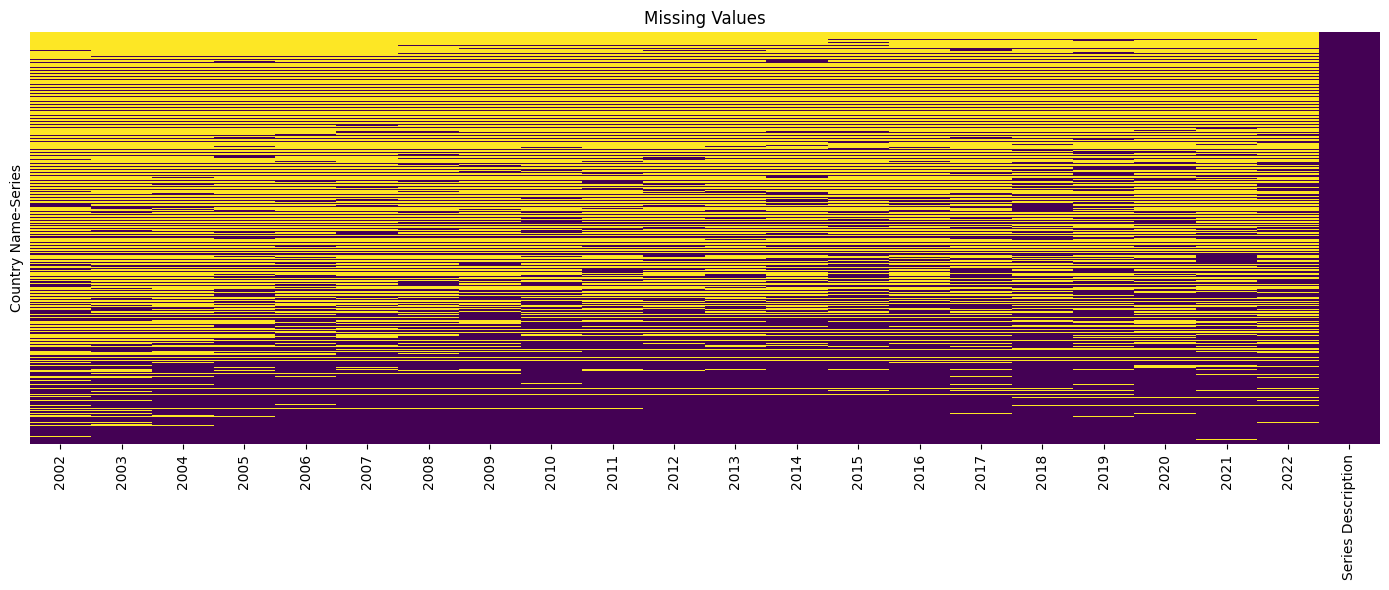

In [ ]:
# plot data to see how much we have
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values')
plt.tight_layout()
plt.show()

In [ ]:
# now that we have identifies criteria for missing data, we can filter out the
# countries and principalities that we can't use
keep_countries = nan_counts[nan_counts < 74].index
df_clean = df.loc[keep_countries]
kept = df_clean.index.get_level_values('Country Name').unique()
kept

Index(['Ethiopia', 'Cambodia', 'Trinidad and Tobago', 'Rwanda', 'Tanzania',
       'China', 'Tajikistan', 'Senegal', 'Philippines', 'Sri Lanka', 'Uganda',
       'Ukraine', 'Kazakhstan', 'Qatar', 'Kyrgyz Republic', 'Uzbekistan',
       'Guatemala', 'Mauritius', 'Bangladesh', 'Tunisia', 'South Africa',
       'Hong Kong SAR, China', 'Iran, Islamic Rep.', 'Azerbaijan',
       'United Kingdom', 'Mali', 'Bosnia and Herzegovina', 'Egypt, Arab Rep.',
       'Singapore', 'Jamaica', 'Pakistan', 'Belarus', 'Mongolia', 'Viet Nam',
       'Venezuela, RB', 'Israel', 'Montenegro', 'Armenia', 'Albania',
       'Australia', 'West Bank and Gaza', 'Korea, Rep.', 'Chile', 'Luxembourg',
       'Georgia', 'Honduras', 'Uruguay', 'Mexico', 'Thailand', 'Canada',
       'Russian Federation', 'Serbia', 'Malta', 'Ireland', 'Denmark',
       'Bolivia', 'Brazil', 'North Macedonia', 'United States', 'Germany',
       'Slovak Republic', 'Poland', 'France', 'El Salvador', 'Moldova',
       'Hungary', 'Belgium', 'Net

In [ ]:
# world map for funsies
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip")
coords = world[['NAME', 'geometry']].copy()
# reprojecting per geopandas warning
coords['coordinates'] = coords['geometry'].to_crs(epsg=3857).centroid.to_crs(epsg=4326)
coords['coordinates'] = coords['geometry'].centroid
coords = coords.rename(columns={'NAME': 'Country Name'})

# check to see if there are naming mismatches between gpd and our list
set(kept) - set(world['ADMIN'])


# manual fixes on kept

name_fix_kept = {
  'Egypt, Arab Rep.' : 'Egypt',
  'Hong Kong SAR, China' : 'Hong Kong S.A.R.',
  'Iran, Islamic Rep.' : 'Iran',
  'Korea, Rep.' : 'South Korea',
  'Kyrgyz Republic' : 'Kyrgyzstan',
  'Russian Federation' : 'Russia',
  'Serbia' : 'Republic of Serbia',
  'Slovak Republic' : 'Slovakia',
  'Tanzania' : 'United Republic of Tanzania',
  'Turkiye' : 'Turkey',
  'United States' : 'United States of America',
  'Venezuela, RB' : 'Venezuela',
  'Viet Nam' : 'Vietnam',
  'West Bank and Gaza' : 'Palestine'
}
kept_fixed = [name_fix_kept.get(c, c) for c in kept]

set(kept_fixed) - set(world['ADMIN'])

df_clean.index = df_clean.index.set_levels(
    df_clean.index.levels[0].map(lambda x: name_fix_kept.get(x, x)),
    level='Country Name'
)

# define a numeric version for querying and plotting
df_clean_numeric = df_clean.apply(pd.to_numeric, errors='coerce')

# indexed numeric version
clean_data_index = df_clean_numeric.sort_index(level=['Country Name', 'Series'])

/tmp/ipykernel_2435/3650780637.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords['coordinates'] = coords['geometry'].centroid


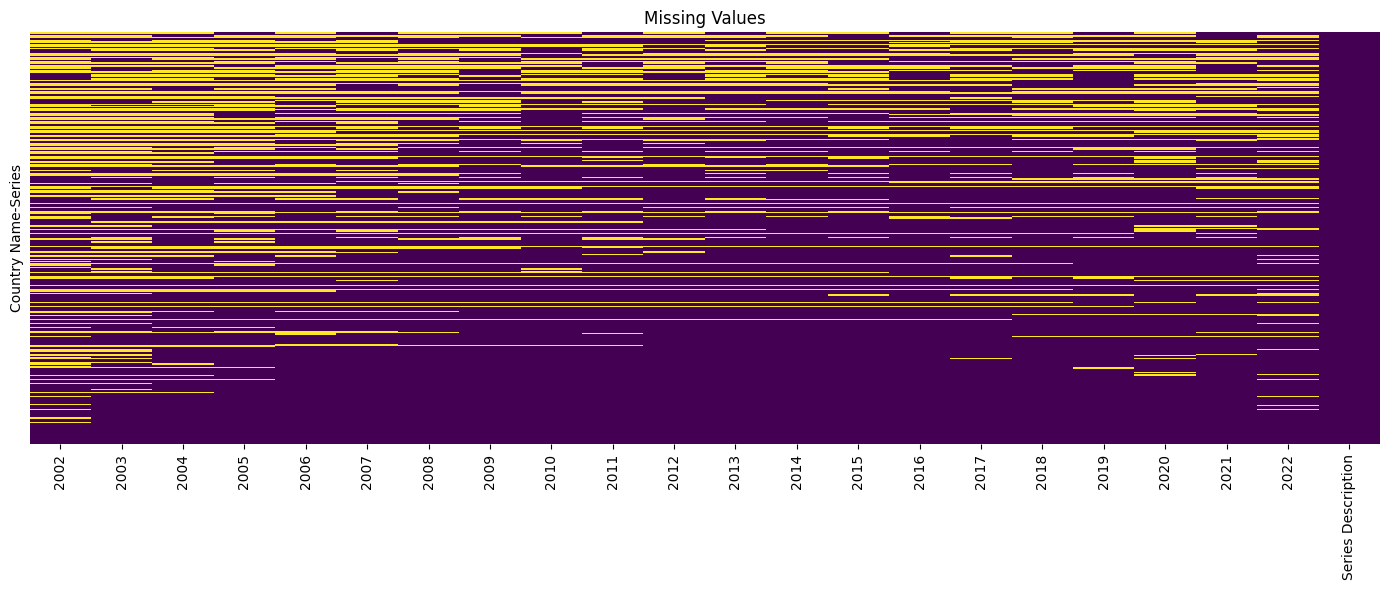

In [ ]:
# new visualization
plt.figure(figsize=(14, 6))
sns.heatmap(df_clean.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values')
plt.tight_layout()
plt.show()

In [ ]:
dropped = df.index.get_level_values('Country Name').unique().difference(kept)
dropped

Index(['Afghanistan', 'Africa Eastern and Southern',
       'Africa Western and Central', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Arab World', 'Argentina',
       ...
       'Turks and Caicos Islands', 'Tuvalu', 'United Arab Emirates',
       'Upper middle income', 'Vanuatu', 'Virgin Islands (U.S.)', 'World',
       'Yemen, Rep.', 'Zambia', 'Zimbabwe'],
      dtype='object', name='Country Name', length=170)

In [ ]:
# get year where we have the least/most data
df_clean_numeric.isnull().sum().sort_values(ascending= True)

,0
2016,96
2014,105
2018,107
2019,108
2015,113
2010,114
2017,114
2012,117
2013,119
2021,120


## Data Visualization

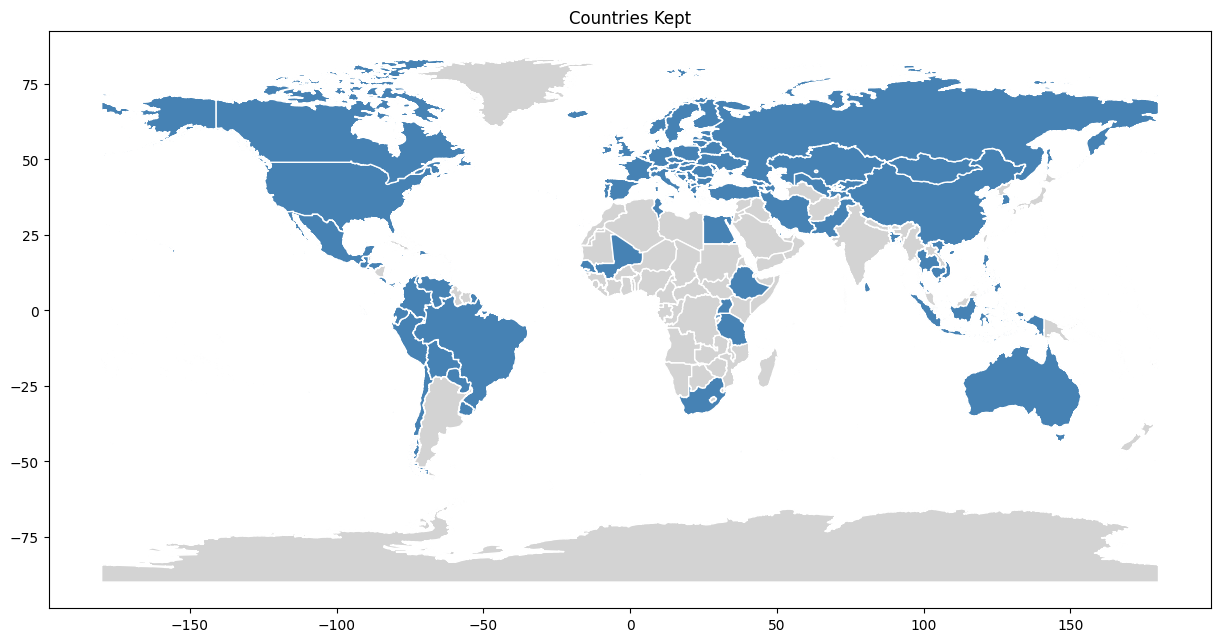

In [ ]:
# plotting the map
fig, ax = plt.subplots(figsize=(15, 10))

# plot all countries as base layer
world.plot(ax=ax, color='lightgrey', edgecolor='white')

# highlight countries
world[world['ADMIN'].isin(kept_fixed)].plot(ax=ax, color='steelblue', edgecolor='white')

plt.title('Countries Kept')
plt.show()

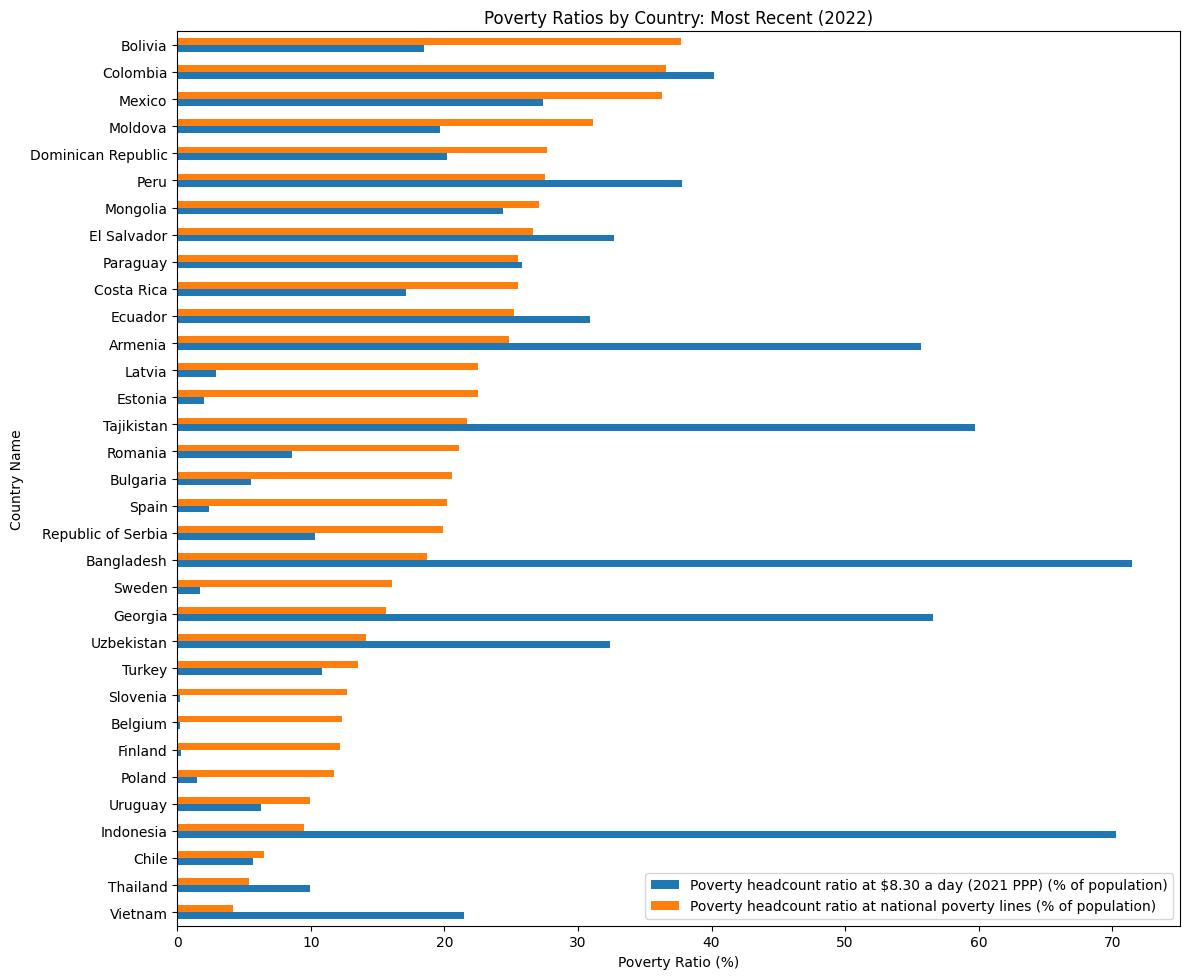

In [ ]:
# kept countries by poverty line and poverty @ $8.30
data1 = df_clean_numeric.xs('poverty_ratio_wage', level='Series')['2022'].dropna().sort_values()
data2 = df_clean_numeric.xs('poverty_ratio_nat', level='Series')['2022'].dropna().sort_values()

descriptions = {
    'poverty_ratio_wage': df_clean.xs('poverty_ratio_wage', level='Series')['Series Description'].iloc[0],
    'poverty_ratio_nat': df_clean.xs('poverty_ratio_nat', level='Series')['Series Description'].iloc[0]
}

combined1 = pd.DataFrame({'poverty_ratio_wage': data1, 'poverty_ratio_nat': data2}).dropna().sort_values('poverty_ratio_nat')
combined1 = combined1.rename(columns=descriptions)

fig, ax = plt.subplots(figsize=(12, len(combined1) * 0.3))
combined1.plot(kind='barh', ax=ax)
plt.title('Poverty Ratios by Country: Most Recent (2022)')
plt.xlabel('Poverty Ratio (%)')
plt.tight_layout()
plt.show()

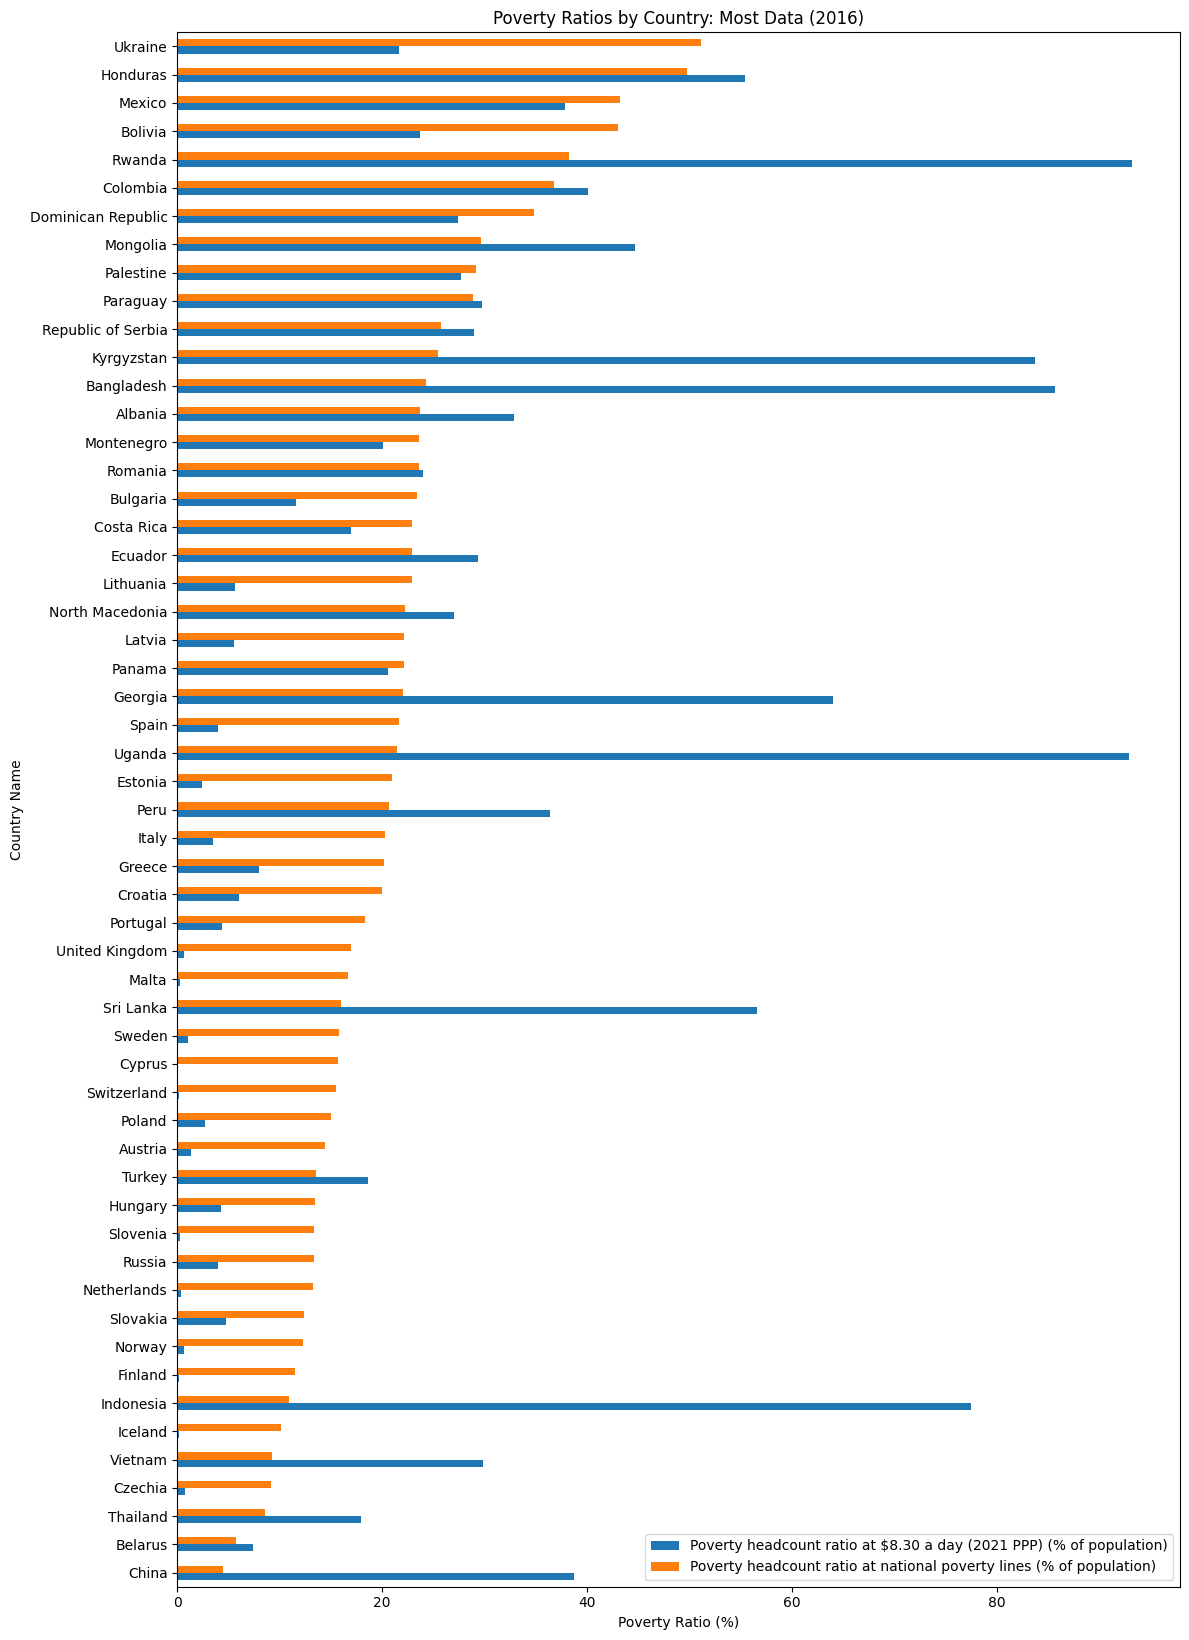

In [ ]:
data3 = df_clean_numeric.xs('poverty_ratio_wage', level='Series')['2016'].dropna().sort_values()
data4 = df_clean_numeric.xs('poverty_ratio_nat', level='Series')['2016'].dropna().sort_values()

combined2 = pd.DataFrame({'poverty_ratio_wage': data3, 'poverty_ratio_nat': data4}).dropna().sort_values('poverty_ratio_nat')
combined2 = combined2.rename(columns=descriptions)

fig, ax = plt.subplots(figsize=(12, len(combined2) * 0.3))
combined2.plot(kind='barh', ax=ax)
plt.title('Poverty Ratios by Country: Most Data (2016)')
plt.xlabel('Poverty Ratio (%)')
plt.tight_layout()
plt.show()

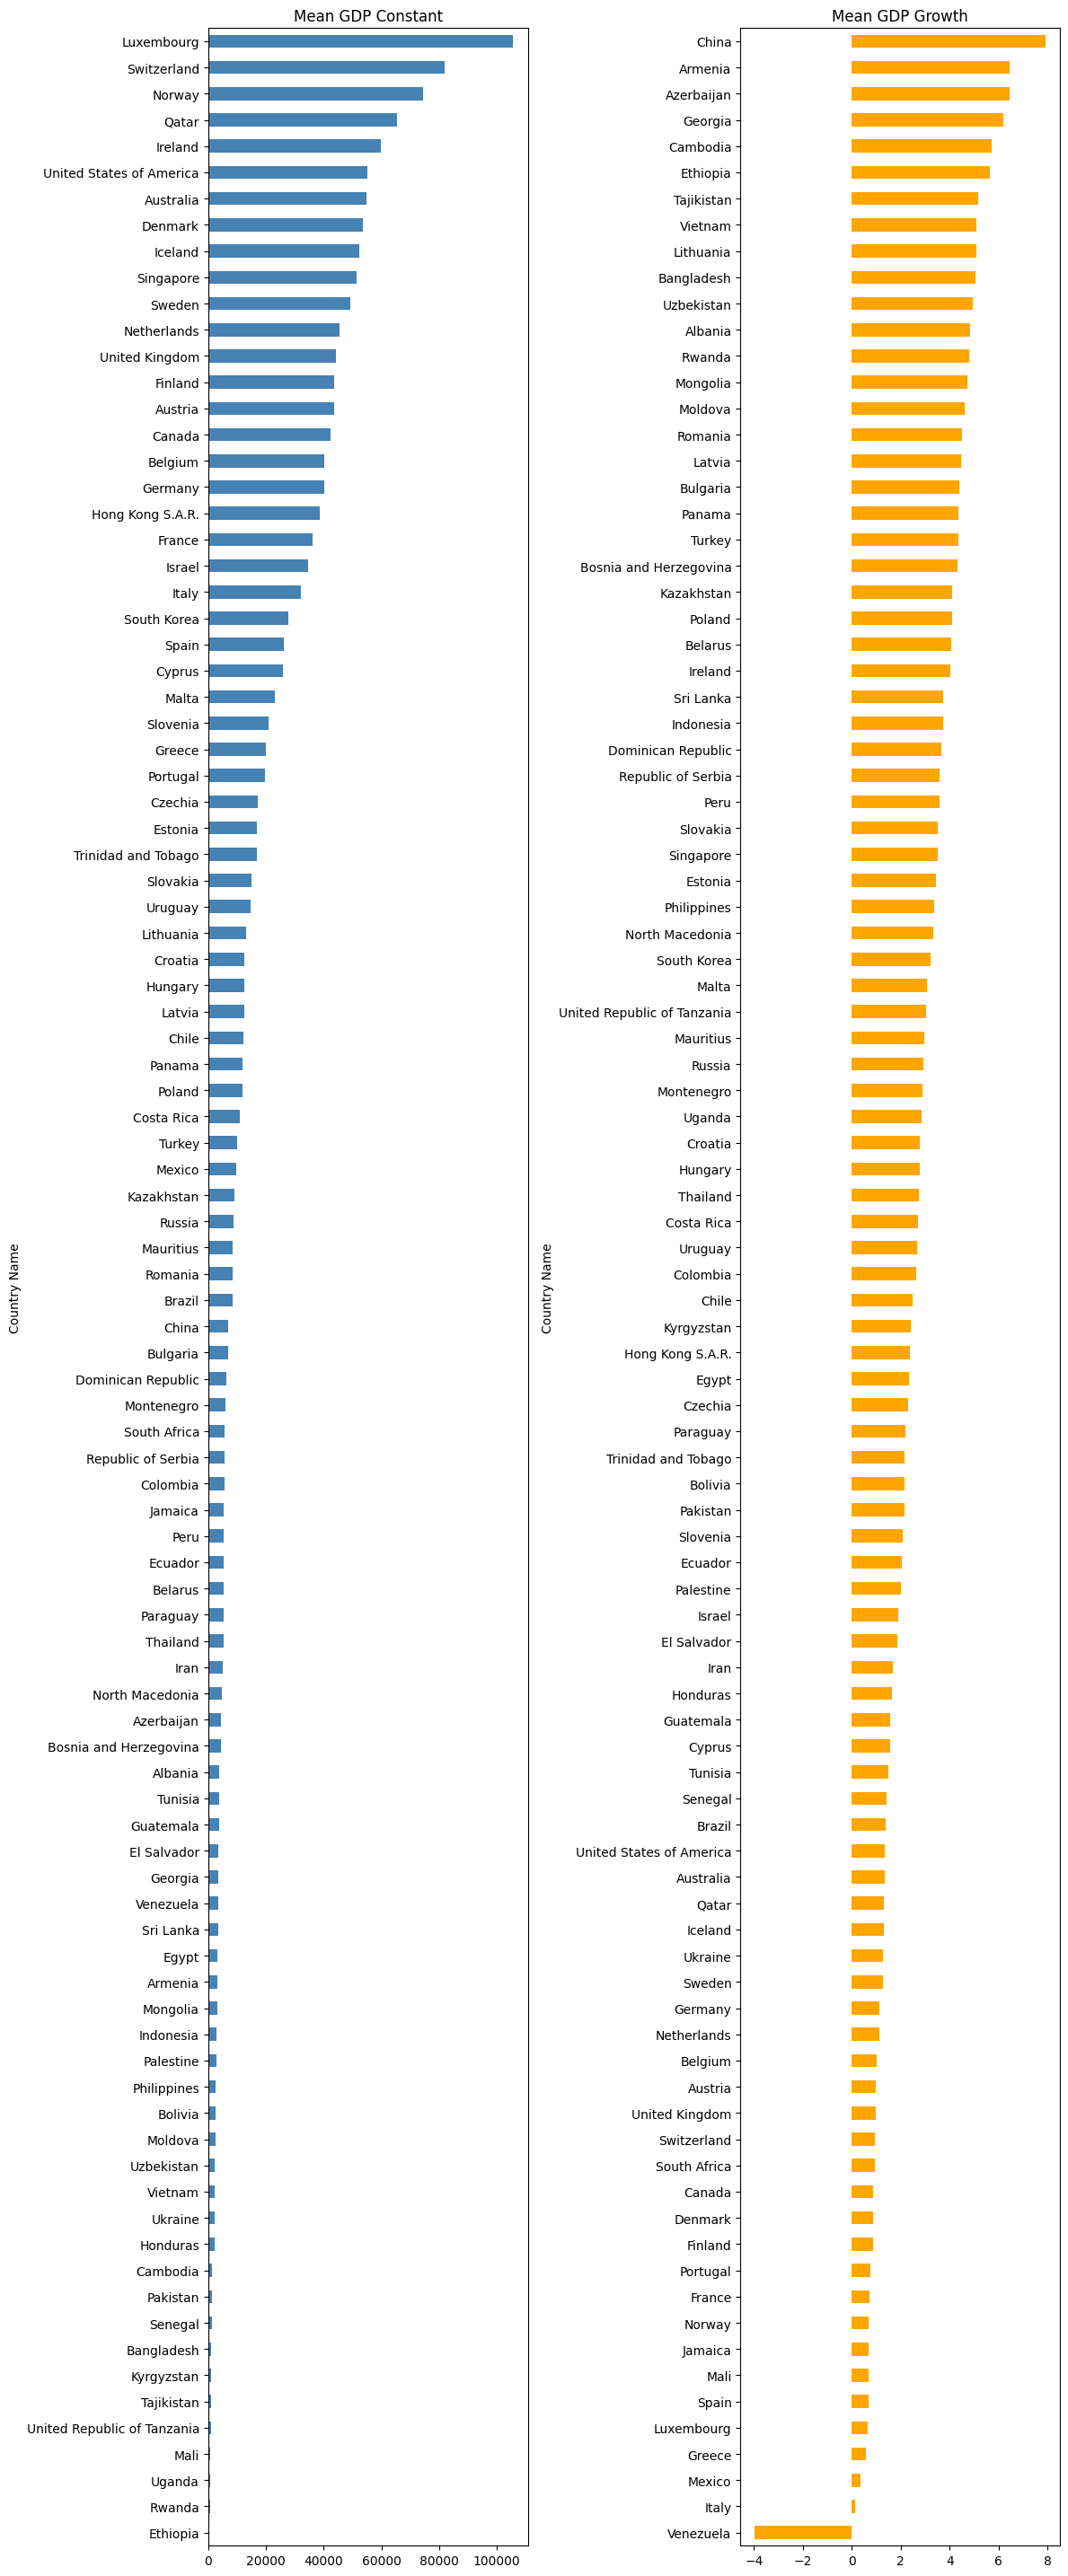

In [ ]:
# averaging the existing gdp data by country
# get sub df with only gdp data
GDP_const_df = clean_data_index.xs('GDP_const', level='Series').drop(columns='Series Description')
GDP_growth_df = clean_data_index.xs('GDP_growth', level='Series').drop(columns='Series Description')


# average the data over the years
GDP_const_df = GDP_const_df.groupby('Country Name').mean().mean(axis = 1)
GDP_growth_df = GDP_growth_df.groupby('Country Name').mean().mean(axis = 1)

# side by side plot of the two gdp averages
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, len(GDP_const_df) * 0.3))
GDP_const_df.sort_values().plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Mean GDP Constant')

GDP_growth_df.sort_values().plot(kind='barh', ax=ax2, color='orange')
ax2.set_title('Mean GDP Growth')

plt.tight_layout()
plt.show()

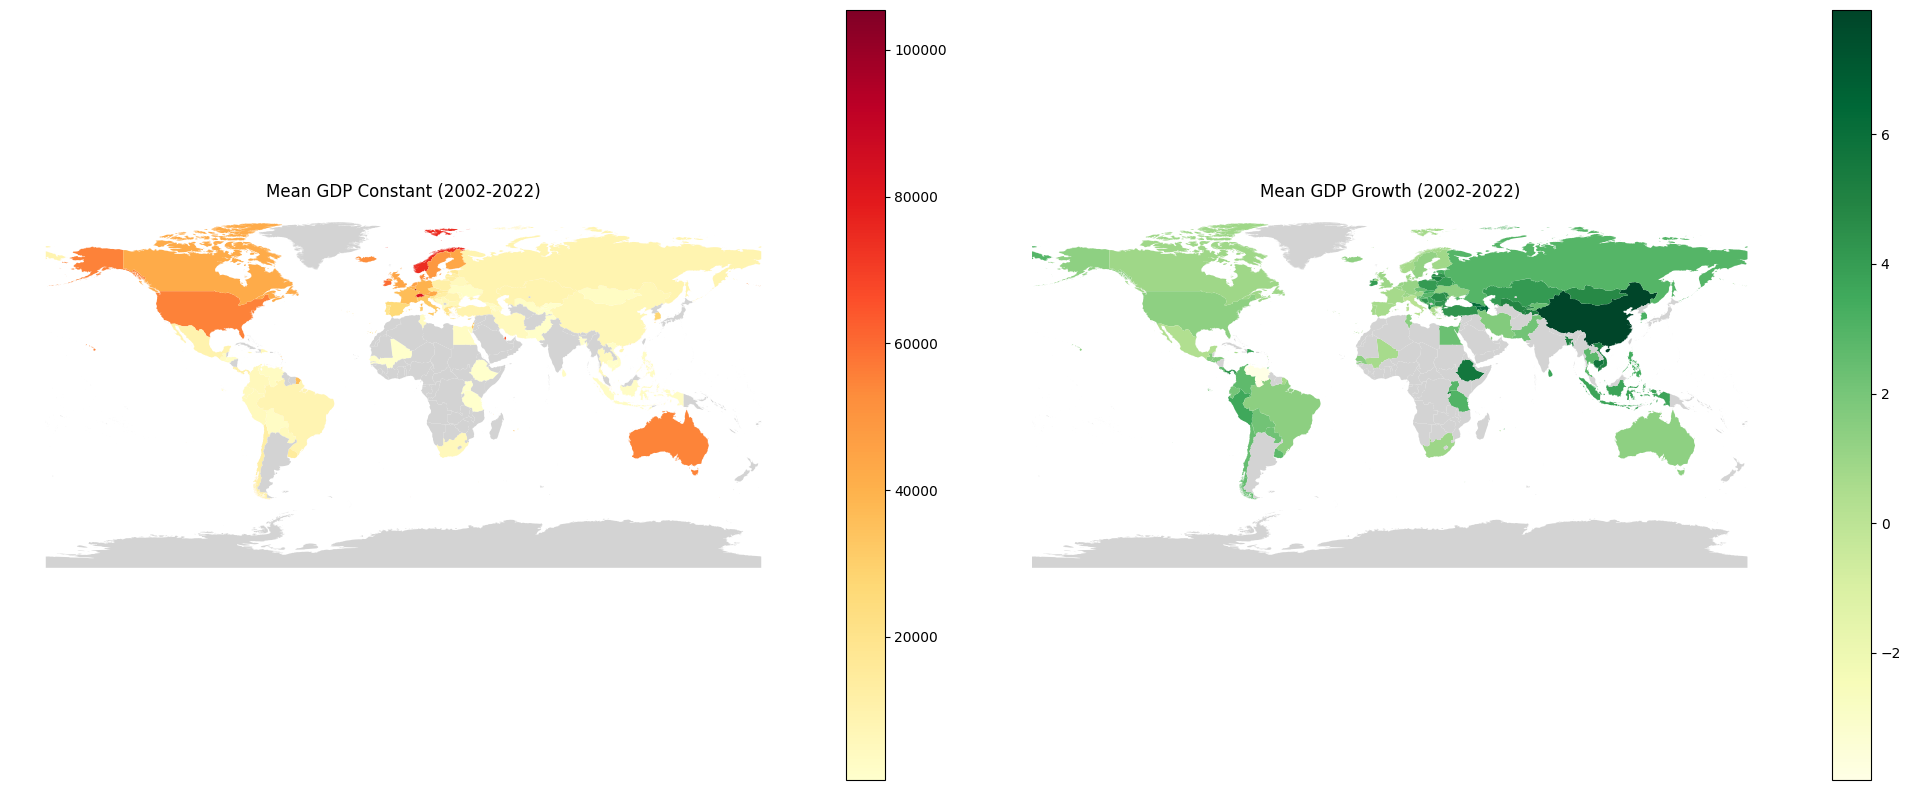

In [ ]:
# chloropleth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for ax, data, col, title, cmap in [
    (ax1, GDP_const_df.to_frame('GDP Constant'), 'GDP Constant', 'Mean GDP Constant (2002-2022)', 'YlOrRd'),
    (ax2, GDP_growth_df.to_frame('GDP Growth'), 'GDP Growth', 'Mean GDP Growth (2002-2022)', 'YlGn')
]:
    world_plot = world.merge(data, left_on='ADMIN', right_index=True, how='left')
    world_plot.plot(column=col, ax=ax, legend=True, cmap=cmap, missing_kwds={'color': 'lightgrey'})
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

##Imputation

In [ ]:
# linear interpolation
data_imput = clean_data_index.interpolate(axis=1, method='linear')

# fill tails
data_imput = data_imput.ffill(axis=1).bfill(axis=1)

# make new data frame where NaN is replaced
data_filled = clean_data_index.copy()
data_filled = data_filled.where(data_filled.notna(), data_imput)

In [ ]:
# find a country/series with NaNs
clean_data_index.isnull().sum(axis=1).sort_values(ascending=False).head(20)

Country Name              Series            
United States of America  poverty_ratio_nat     22
Australia                 poverty_ratio_nat     22
Trinidad and Tobago       poverty_ratio_wage    22
                          poverty_ratio_nat     22
Singapore                 poverty_ratio_wage    22
South Korea               poverty_ratio_nat     22
Cambodia                  poverty_ratio_wage    22
Brazil                    poverty_ratio_nat     22
Singapore                 poverty_ratio_nat     22
Canada                    poverty_ratio_nat     22
Hong Kong S.A.R.          poverty_ratio_nat     22
                          poverty_ratio_wage    22
Israel                    poverty_ratio_nat     22
Iran                      poverty_ratio_nat     22
Qatar                     poverty_ratio_nat     22
                          poverty_ratio_wage    21
Kyrgyzstan                ed_attain_fem         21
                          ed_attain_total       21
                          ed_attain_male        21
Guatemala                 poverty_ratio_nat     20
dtype: int64

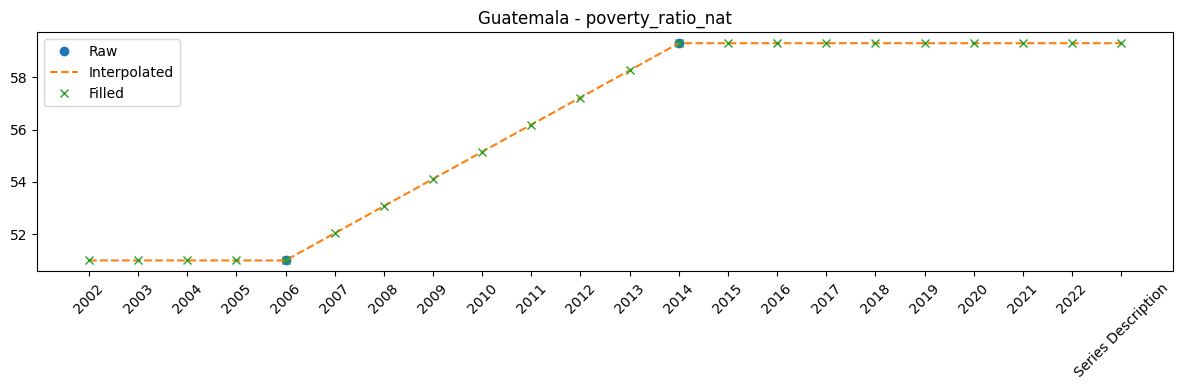

In [ ]:
# test viz
country = 'Guatemala'
series = 'poverty_ratio_nat'


raw = clean_data_index.xs((country, series), level=('Country Name', 'Series')).squeeze()
interp = data_imput.xs((country, series), level=('Country Name', 'Series')).squeeze()
filled = data_filled.xs((country, series), level=('Country Name', 'Series')).squeeze()

x = [str(c) for c in raw.index]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x, raw.values, label='Raw', linestyle='none', marker='o')
ax.plot(x, interp.values, label='Interpolated', linestyle='--')
ax.plot(x, filled.values, label='Filled', linestyle='none', marker='x')
plt.xticks(rotation=45)
plt.title(f'{country} - {series}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# saving dataframes as csv
df_clean.to_csv('clean_20_years.csv')
df_clean_numeric.to_csv('clean_20_years_numeric.csv')

Regression


In [ ]:
df_clean.head()

2002               2003  \
Country Name Series                                                  
Ethiopia     ed_attain_fem                  NaN                NaN   
             ed_attain_male                 NaN                NaN   
             ed_attain_total                NaN                NaN   
             GDP_const         256.066635883709   243.076666020009   
             GDP_growth       -1.52885894017255  -5.07288652380292   

                                          2004              2005  \
Country Name Series                                                
Ethiopia     ed_attain_fem                 NaN  3.10139926738417   
             ed_attain_male                NaN  6.78371095188624   
             ed_attain_total               NaN  4.84484068131152   
             GDP_const        267.923513391712  290.833381425059   
             GDP_growth        10.221815108184   8.5508986289875   

                                          2006              2007  \
Country Name Series                                                
Ethiopia     ed_attain_fem                 NaN  4.51999998092651   
             ed_attain_male                NaN  9.60999965667725   
             ed_attain_total               NaN  7.01999998092651   
             GDP_const        313.013896721503  338.799064654308   
             GDP_growth       7.62653694970021  8.23770708038126   

                                          2008              2009  \
Country Name Series                                                
Ethiopia     ed_attain_fem                 NaN               NaN   
             ed_attain_male                NaN               NaN   
             ed_attain_total               NaN               NaN   
             GDP_const        364.642208155735  385.632419711374   
             GDP_growth       7.62786742867665   5.7563855983106   

                                          2010              2011  ...  \
Country Name Series                                               ...   
Ethiopia     ed_attain_fem                 NaN  5.65999984741211  ...   
             ed_attain_male                NaN  12.6899995803833  ...   
             ed_attain_total               NaN  8.84000015258789  ...   
             GDP_const        421.898622378633  455.909628648555  ...   
             GDP_growth        9.4043448666486  8.06141676362226  ...   

                                          2014              2015  \
Country Name Series                                                
Ethiopia     ed_attain_fem                 NaN               NaN   
             ed_attain_male                NaN               NaN   
             ed_attain_total               NaN               NaN   
             GDP_const        556.362532243867  597.912113218663   
             GDP_growth       7.33861859355025   7.4680767605293   

                                          2016              2017  \
Country Name Series                                                
Ethiopia     ed_attain_fem    4.78073978424072               NaN   
             ed_attain_male   9.38784027099609               NaN   
             ed_attain_total  6.92962980270386               NaN   
             GDP_const        636.835680951429   678.98541915757   
             GDP_growth        6.5099145630674  6.61862070026751   

                                          2018              2019  \
Country Name Series                                                
Ethiopia     ed_attain_fem                 NaN  5.88137006759644   
             ed_attain_male                NaN  12.1695203781128   
             ed_attain_total               NaN  8.87446022033691   
             GDP_const         705.96881207336  744.702789753973   
             GDP_growth       3.97407545942133  5.48664148021712   

                                          2020              2021  \
Country Name Series                                                
Ethiopia     ed_attain_fem                

In [ ]:
# import ordinary least squares
import statsmodels.formula.api as smf

# create model
model = smf.ols('ed_attain_total ~ poverty_ratio_wage + log(GDP_const)', data=df_clean)

# fit model
results = model.fit()

# print results
print(results.summary)

PatsyError: Error evaluating factor: NameError: name 'ed_attain_total' is not defined
    ed_attain_total ~ poverty_ratio_wage + GDP_const
    ^^^^^^^^^^^^^^^